In [2]:
import pandas as pd
import matplotlib.pyplot as plt


In [3]:
import pandas as pd

# 1️⃣ Mappa mese → file CSV
month_files = {
    3: 'marzo_daily_avg_per_zone.csv',
    5: 'maggio_daily_avg_per_zone.csv',
    8: 'agosto_daily_avg_per_zone.csv',
    9: 'settembre_daily_avg_per_zone.csv'
}

# 2️⃣ Lista per contenere DataFrame dei singoli mesi
dfs = []

for month, file in month_files.items():
    # Leggi CSV (modifica sep se necessario)
    df = pd.read_csv(file, sep=',')  # oppure sep='\t' se tab-separated

    # Normalizza nomi colonne
    df.columns = df.columns.str.strip()

    # Crea colonna 'data' a partire da 'Numero_Giorno' e mese corrente
    df['data'] = pd.to_datetime(f'2025-{month:02d}-01') + pd.to_timedelta(df['Numero_Giorno'] - 1, unit='d')

    dfs.append(df)

# 3️⃣ Unisci tutti i DataFrame
df_all = pd.concat(dfs, ignore_index=True)

# 4️⃣ Trasforma in wide format (data, aeroporto, fiera)
df_wide = df_all.pivot(index='data', columns='Zona', values='P').reset_index()
df_wide.columns.name = None
df_wide = df_wide.rename(columns={'Aeroporto':'aeroporto', 'Fiera':'fiera'})

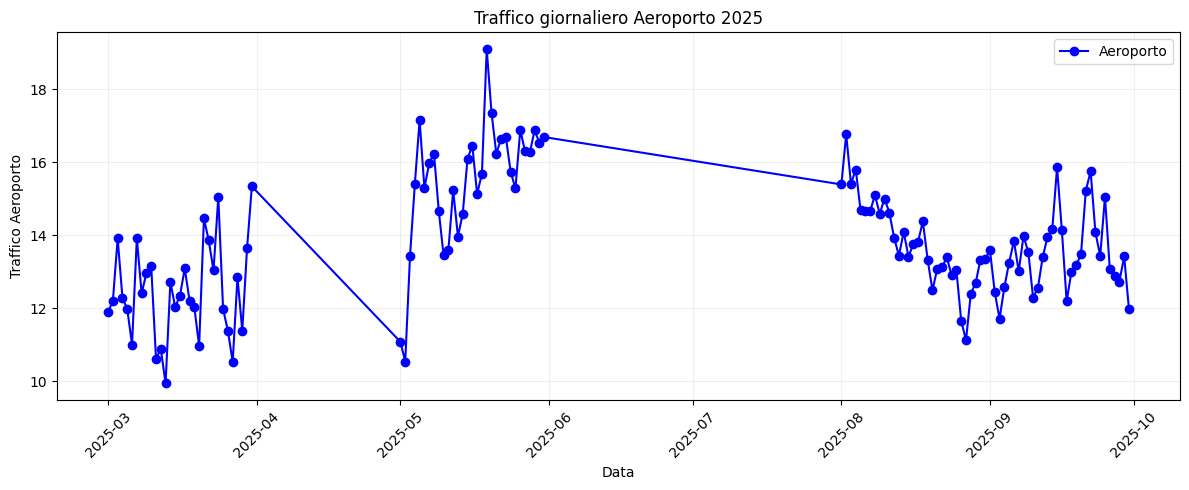

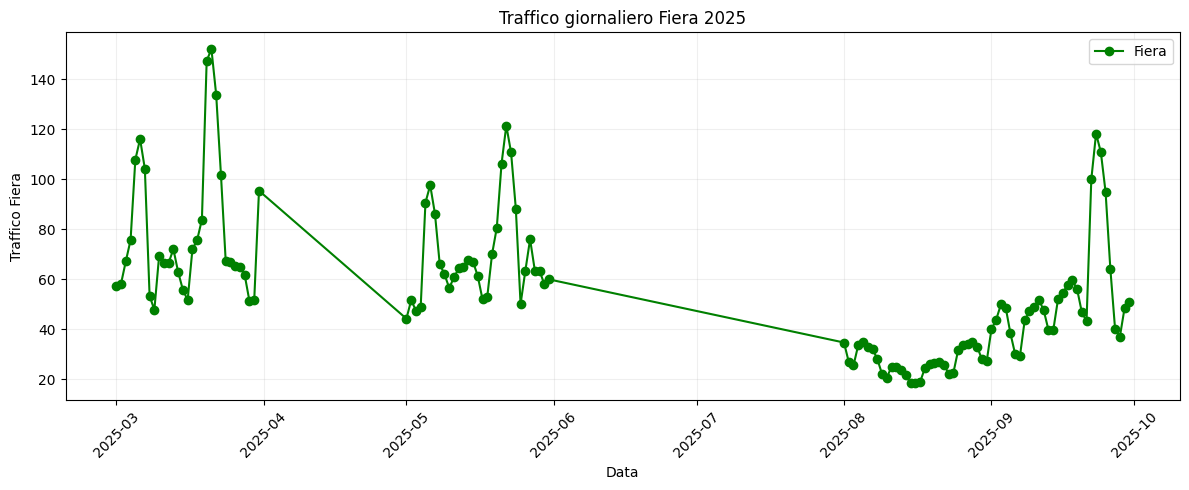

In [4]:

# ------------------------------
# Grafico 1: Aeroporto
# ------------------------------
plt.figure(figsize=(12,5))
plt.plot(df_wide['data'], df_wide['aeroporto'], label='Aeroporto', marker='o', color='blue')
plt.xlabel('Data')
plt.ylabel('Traffico Aeroporto')
plt.title('Traffico giornaliero Aeroporto 2025')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------
# Grafico 2: Fiera
# ------------------------------
plt.figure(figsize=(12,5))
plt.plot(df_wide['data'], df_wide['fiera'], label='Fiera', marker='o', color='green')
plt.xlabel('Data')
plt.ylabel('Traffico Fiera')
plt.title('Traffico giornaliero Fiera 2025')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
from scipy.signal import find_peaks

# Esempio: df_wide già contiene 'data' come datetime
df_wide["data"] = pd.to_datetime(df_wide["data"])

# 1️⃣ Trova i picchi
peaks, properties = find_peaks(df_wide["fiera"], prominence=30)
# Crea una copia esplicita per lavorare sui picchi
df_peaks = df_wide.iloc[peaks].copy()

# Ora puoi aggiungere colonne senza warning
df_peaks["year_week"] = df_peaks["data"].dt.isocalendar().week
df_peaks["year"] = df_peaks["data"].dt.isocalendar().year

peak_weeks = set(zip(df_peaks["year"], df_peaks["year_week"]))

# 3️⃣ Crea colonna inizializzata a 0
df_wide["evento_fiera"] = 0

# 4️⃣ Imposta 1 per sabati e domeniche delle settimane con picco
for idx, row in df_wide.iterrows():
    year = row["data"].isocalendar().year
    week = row["data"].isocalendar().week
    weekday = row["data"].weekday()  # 0=lunedì, 5=sabato, 6=domenica
    if (year, week) in peak_weeks and weekday >= 5:
        df_wide.at[idx, "evento_fiera"] = 1

df_wide

,data,aeroporto,fiera,evento_fiera
0,2025-03-01,11.898493,57.314352,0
1,2025-03-02,12.190898,58.357870,0
2,2025-03-03,13.906398,67.268056,0
3,2025-03-04,12.280733,75.725810,0
4,2025-03-05,11.969858,107.874595,0
...,...,...,...,...
118,2025-09-26,13.070700,64.362269,0
119,2025-09-27,12.884752,40.171181,1
120,2025-09-28,12.722961,37.002315,1
121,2025-09-29,13.415189,48.592477,0


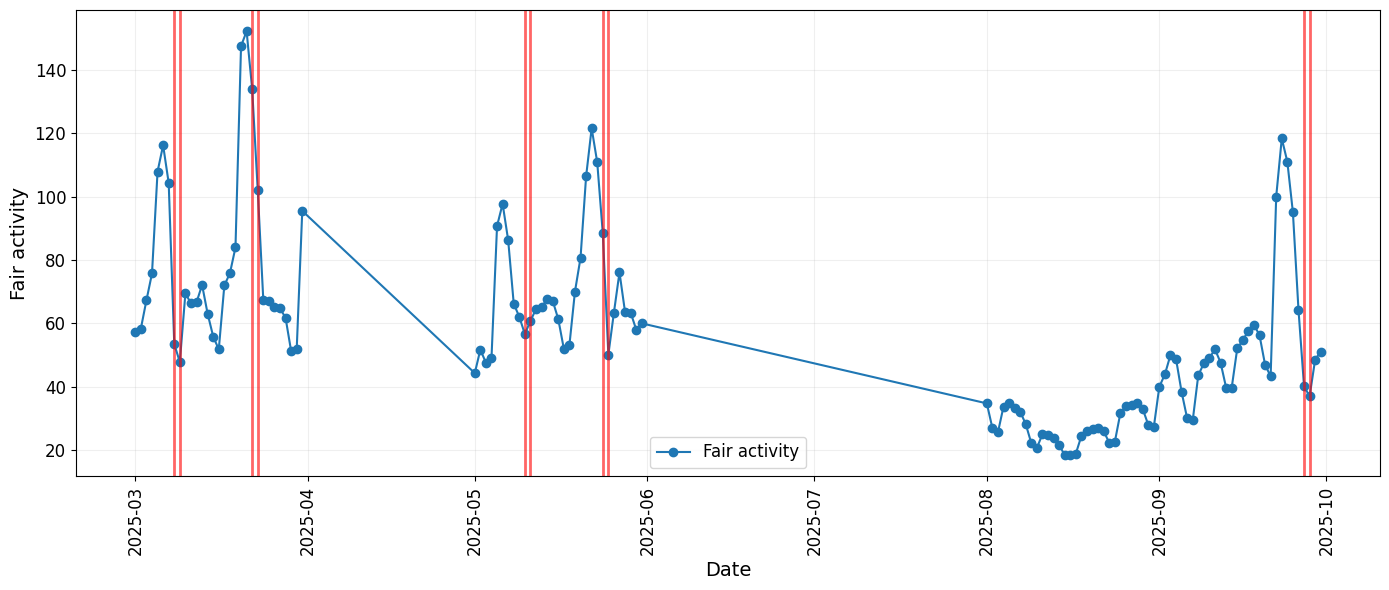

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Assicurati che 'data' sia datetime
df_wide["data"] = pd.to_datetime(df_wide["data"])

plt.figure(figsize=(14,6))

# Linea principale
plt.plot(df_wide["data"], df_wide["fiera"], marker='o', label="Fair activity")

# Barre rosse verticali per giorni peak
for d in df_wide[df_wide["evento_fiera"] == 1]["data"]:
    plt.axvline(x=d, color='red', alpha=0.6, linewidth=2)

# Formattazione con font più grande
plt.xlabel("Date", fontsize=14)
plt.ylabel("Fair activity", fontsize=14)
plt.xticks(fontsize=12, rotation=90)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.2)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


In [7]:
from scipy.signal import find_peaks

# Trova i picchi verso il basso (minimi locali)
peaks_airport_down, _ = find_peaks(df_wide["aeroporto"], prominence=2)
df_peaks_airport_down = df_wide.iloc[peaks_airport_down].copy()

# Aggiungi info settimana e anno
df_peaks_airport_down["year_week"] = df_peaks_airport_down["data"].dt.isocalendar().week
df_peaks_airport_down["year"] = df_peaks_airport_down["data"].dt.isocalendar().year

peak_weeks_airport_down = set(zip(df_peaks_airport_down["year"], df_peaks_airport_down["year_week"]))

# Crea colonna weekend_peak verso il basso
df_wide["evento_aeroporto"] = 0

for idx, row in df_wide.iterrows():
    year = row["data"].isocalendar().year
    week = row["data"].isocalendar().week
    weekday = row["data"].weekday()  # 0=lunedì, 5=sabato, 6=domenica
    if (year, week) in peak_weeks_airport_down and weekday >= 5:
        df_wide.at[idx, "evento_aeroporto"] = 1

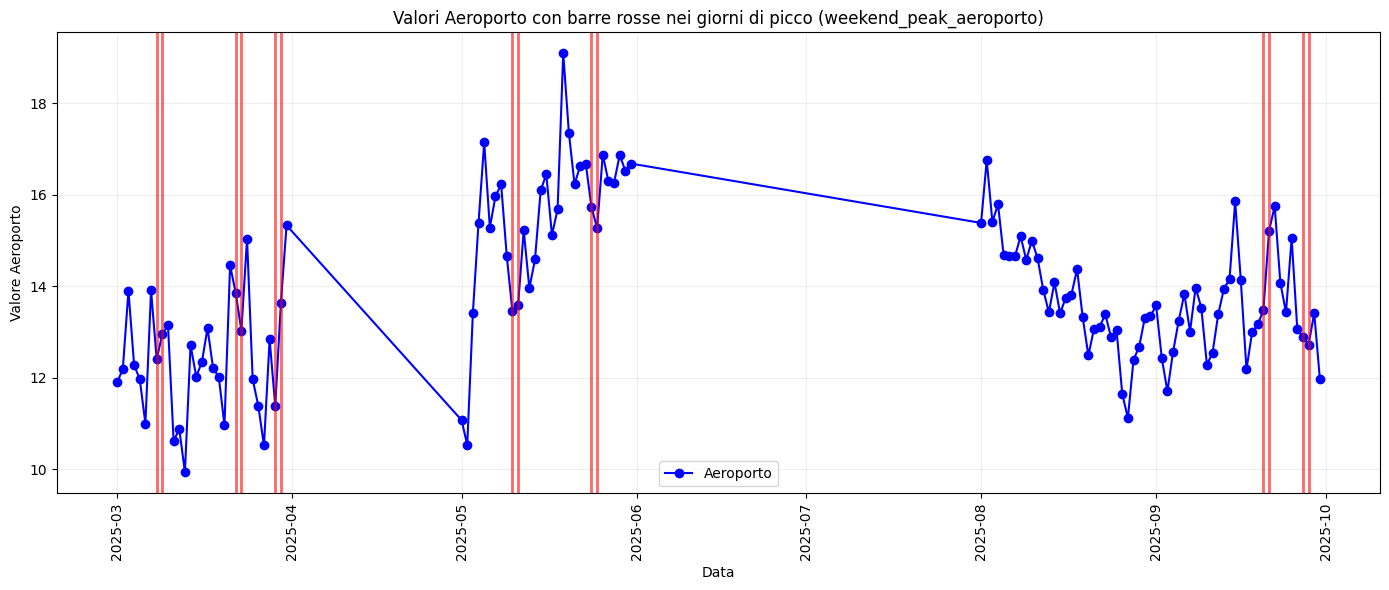

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Linea principale
plt.plot(df_wide["data"], df_wide["aeroporto"], label="Aeroporto", marker='o', color='blue')

# Barre rosse verticali per giorni peak
for d in df_wide[df_wide["evento_aeroporto"] == 1]["data"]:
    plt.axvline(x=d, color='red', alpha=0.6, linewidth=2)

# Formattazione
plt.xlabel("Data")
plt.ylabel("Valore Aeroporto")
plt.title("Valori Aeroporto con barre rosse nei giorni di picco (weekend_peak_aeroporto)")
plt.xticks(rotation=90)
plt.grid(True, alpha=0.2)
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
df_wide

,data,aeroporto,fiera,evento_fiera,evento_aeroporto
0,2025-03-01,11.898493,57.314352,0,0
1,2025-03-02,12.190898,58.357870,0,0
2,2025-03-03,13.906398,67.268056,0,0
3,2025-03-04,12.280733,75.725810,0,0
4,2025-03-05,11.969858,107.874595,0,0
...,...,...,...,...,...
118,2025-09-26,13.070700,64.362269,0,0
119,2025-09-27,12.884752,40.171181,1,1
120,2025-09-28,12.722961,37.002315,1,1
121,2025-09-29,13.415189,48.592477,0,0


In [10]:
# Salva in CSV
df_wide.to_csv('eventi_aeroporto_fiera.csv', index=False)
